# Probabilistic Linear Inference on Sobolev Spaces

## The Continuous Problem

We consider the problem of inferring an unknown model parameter $m$ from noisy observations $\mathbf{\tilde{d}}$, where $m$ lies in a Sobolev space $\mathcal{M} = H^s([0,1])$ and $\mathbf{\tilde{d}} \in \mathcal{D}$, a finite‑dimensional Euclidean data space $\mathcal{D} \cong \mathbb{R}^{N_d}$ ($N_d \in \mathbb{N}$ is the number of data).

The relationship between the model and the data is described by a forward operator:
$$
G: \mathcal{M} \to \mathcal{D}, \quad [G(m)]_i = \langle K_i, m \rangle_{\mathcal{M}}
$$
assumed to be linear and bounded. The observed data is modeled as:
$$
\mathbf{\tilde{d}} = G(m) + \bm{\eta},
$$
where $\bm{\eta} \sim \mathcal{N}(0, \mathbf{C}_{\mathcal{D}})$ represents additive Gaussian noise with known symmetric positive‑definite covariance matrix $\mathbf{C}_{\mathcal{D}} \in \mathbb{R}^{N_d \times N_d}$.

To regularize this ill‑posed inverse problem, we adopt a Bayesian framework. We model the unknown $m$ as a random variable and assign a Gaussian prior:
$$
m \sim \mu_{\mathcal{M}}^0 := \mathcal{N}(m_0, C_0),
$$
where $m_0 \in \mathcal{M}$ is the prior mean, and $C_0: \mathcal{M} \to \mathcal{M}$ is a symmetric, positive‑definite trace‑class covariance operator.

**Sobolev Space Setup**  
Working in Sobolev spaces $H^s([0,1])$ provides natural regularity for the model. The inner product involves derivatives up to order $s$, ensuring smoothness of the inferred model. We use the Laplacian operator $L$ with appropriate boundary conditions to define the space structure.

**Gaussian measure in terms of $C_0$**  
Under this formulation the Gaussian prior can be equivalently written via its Karhunen–Loève expansion: if $\{\varphi_k\}$ are eigenfunctions of $C_0$ with eigenvalues $\{\lambda_k\}$, then
$$
m = m_0 + \sum_{k=1}^\infty \sqrt{\lambda_k} \,\bm{\xi}_k\,\varphi_k,
\qquad
\bm{\xi}_k \overset{i.i.d.}{\sim} \mathcal{N}(0,1).
$$
Thus $C_0$ controls the decay of $\lambda_k$ and hence the regularity of samples from $\mu_{\mathcal{M}}^0$.

The goal of Bayesian inversion is to compute or characterize the posterior distribution $\mu_{\mathcal{M}}^{\mathbf{\tilde{d}}}$ of $m$ conditioned on the observed data $\mathbf{\tilde{d}}$. According to Bayes' theorem (in the infinite‑dimensional setting), the posterior is given formally by:
$$
\frac{d\mu_{\mathcal{M}}^{\mathbf{\tilde{d}}}}{d\mu_{\mathcal{M}}^0}(m) \;\propto\; \exp\!\left[-\tfrac12\,\|G(m)-\mathbf{\tilde{d}}\|_{\mathbf{C}^{-1}_{\mathcal{D}}}^2\right],
$$
where the data‐misfit norm is
$$
\|\mathbf{v}\|_{\mathbf{C}^{-1}_{\mathcal{D}}}^2 := \mathbf{v}^\top\,\mathbf{C}_{\mathcal{D}}^{-1}\,\mathbf{v}.
$$

Bayesian inference takes this a step further and asks for a specific property of the true model. Let 
$$
\mathcal{T} \colon \mathcal{M} \to \mathcal{P}, \quad [\mathcal{T}(m)]_i = \langle T_i, m \rangle_{\mathcal{M}}
$$
be a linear and bounded mapping that takes in a model and outputs a finite number of real scalars that represent some local or global property of the model, such as a global average, a local average, a local gradient average, a Fourier basis coefficient, etc. $T_i \in \mathcal{M}$ are the target kernels. The property space $\mathcal{P}$ is a finite dimensional Hilbert space equivalent to $\mathbb{R}^{N_p}$ where $N_p \in \mathbb{N}$ is the number of "properties" to be sought. By pushing the infinite-dimensional posterior measure $\mu_{\mathcal{M}}^{\mathbf{\tilde{d}}}$ through the property mapping $\mathcal{T}$ we obtain the (Gaussian) property measure 
$$
\mu_{\mathcal{P}} = \mathcal{T}_*\mu_{\mathcal{M}}^{\mathbf{\tilde{d}}}
$$

## Continuous Solution

Using a Bayesian update we obtain the posterior measure on the model space $\mu_{\mathcal{M}}^{\mathbf{\tilde{d}}} = \mathcal{N}(\tilde{m}, C_{\mathcal{M}})$ where:
$$
\boxed{
C_{\mathcal{M}} = \left( G^* \mathbf{C}_{\mathcal{D}}^{-1} G + C_0^{-1} \right)^{-1}, \quad
\tilde{m} = C_{\mathcal{M}} \left( G^* \mathbf{C}_{\mathcal{D}}^{-1} \mathbf{\tilde{d}} + C_0^{-1}m_0 \right).
}
$$

Then we can obtain the property measure from the model posterior $\mu_{\mathcal{P}} = \mathcal{N}(\mathbf{\tilde{p}}, \mathbf{C}_{\mathcal{P}})$:
$$
\boxed{
\mathbf{\tilde{p}} = \mathcal{T}(\tilde{m}), \quad \mathbf{C}_{\mathcal{P}} = \mathcal{T} C_{\mathcal{M}} \mathcal{T}^*.
}
$$

### Importing the necessary packages

In [1]:
from intervalinf import IntervalDomain, Lebesgue, Sobolev, Function, BoundaryConditions
from intervalinf import IntegrationConfig, ParallelConfig, LebesgueIntegrationConfig, LebesgueParallelConfig
from intervalinf.providers import NormalModesProvider, BumpFunctionProvider
from intervalinf.operators import InverseLaplacian, BesselSobolevInverse, SOLAOperator, Laplacian
from intervalinf.sampling import KLSampler
from pygeoinf import EuclideanSpace, GaussianMeasure, LinearForwardProblem, CholeskySolver
from pygeoinf import LinearBayesianInversion
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

# Set-up folder for saving figures
import os
figures_folder = 'pli_sobolev_figures'
if not os.path.exists(figures_folder):
    os.makedirs(figures_folder)

In [2]:
# =============================================================================
# INTEGRATION AND PARALLEL CONFIGURATION
# =============================================================================

# Integration configuration for Lebesgue space
# - method: Integration method ('simpson', 'trapz', 'quad')
# - n_points: Number of integration points
Lebesgue_integration_cfg = LebesgueIntegrationConfig(
    inner_product=IntegrationConfig(method='simpson', n_points=1000),
    dual=IntegrationConfig(method='simpson', n_points=1000),
    general=IntegrationConfig(method='simpson', n_points=1000)
)

# Integration configuration for Laplacian operator (spectral method)
# - method: Integration method ('simpson', 'trapz', 'quad')
# - n_points: Number of integration points
laplacian_integration_cfg = IntegrationConfig(
    method='simpson',
    n_points=1000
)

# Integration configuration for SOLA operators (G and T)
# These use default config but you can customize here
sola_integration_cfg = IntegrationConfig(
    method='simpson',
    n_points=1000
)

# Parallel configuration for dense matrix computations
# - enabled: Whether to use parallel processing
# - n_jobs: Number of parallel jobs (-1 = use all cores)
parallel_cfg = ParallelConfig(
    enabled=True,
    n_jobs=16
)

# Integration/Parallel config for Lebesgue space
# (uses hierarchical config: inner_product, dual, general)
# If you want to customize Lebesgue configs, you can specify them explicitly:
# lebesgue_integration_cfg = LebesgueIntegrationConfig(
#     inner_product=IntegrationConfig(method='simpson', n_points=1000),
#     dual=IntegrationConfig(method='simpson', n_points=1000),
#     general=IntegrationConfig(method='simpson', n_points=1000)
# )
# lebesgue_parallel_cfg = LebesgueParallelConfig(
#     inner_product=ParallelConfig(enabled=True, n_jobs=30),
#     dual=ParallelConfig(enabled=True, n_jobs=30),
#     general=ParallelConfig(enabled=True, n_jobs=30)
# )

print("Configuration loaded:")
print(f"  Laplacian integration: {laplacian_integration_cfg.method}, {laplacian_integration_cfg.n_points} points")
print(f"  SOLA integration: {sola_integration_cfg.method}, {sola_integration_cfg.n_points} points")
print(f"  Parallel processing: {'enabled' if parallel_cfg.enabled else 'disabled'}, {parallel_cfg.n_jobs} jobs")

Configuration loaded:
  Laplacian integration: simpson, 1000 points
  SOLA integration: simpson, 1000 points
  Parallel processing: enabled, 16 jobs


## Configuration

Control the inference workflow with the flag below.

In [3]:
# =============================================================================
# CONFIGURATION FLAGS
# =============================================================================

# Set to True to compute and visualize the model posterior
# Set to False to skip model posterior and go directly to property posterior
COMPUTE_MODEL_POSTERIOR = True

print(f"Configuration:")
print(f"  COMPUTE_MODEL_POSTERIOR = {COMPUTE_MODEL_POSTERIOR}")
if COMPUTE_MODEL_POSTERIOR:
    print("  → Will compute model posterior, then push to property space")
else:
    print("  → Will skip model posterior and compute property posterior directly")
    print("  → Expected speedup: ~4-5x faster")

Configuration:
  COMPUTE_MODEL_POSTERIOR = True
  → Will compute model posterior, then push to property space


## Creating the Spaces

We create the function domain as an interval $[0,1]$ and define a Sobolev space $H^s([0,1])$ as our model space. The Sobolev space structure is defined through:
- A Laplacian operator $L$ with boundary conditions
- Sobolev parameter $s$ (regularity order)
- Scaling parameter $k$ (controls the norm strength)

In [4]:
# Create a function domain and spaces
function_domain = IntervalDomain(0, 1)

# Create Laplacian operator for Sobolev space definition
M_laplacian = Lebesgue(100, function_domain, basis='cosine',
                       integration_config=Lebesgue_integration_cfg,
                       parallel_config=parallel_cfg,)
bcs = BoundaryConditions(bc_type='neumann', left=0, right=0)


# Create Sobolev space
s_sobolev = 3
length_scale_sobolev = np.power(10, -0.75)
overall_variance_sobolev = np.power(10, 0.3)
k_sobolev = np.power(overall_variance_sobolev, -0.5/s_sobolev)
alpha = (length_scale_sobolev**2) * k_sobolev**2
laplacian = Laplacian(M_laplacian, bcs, alpha, method='spectral',
                      dofs=100, n_samples=2048,
                      integration_config=laplacian_integration_cfg)
L = laplacian
M = Sobolev(100, function_domain, s_sobolev, k_sobolev, L, basis='cosine')
#M = Lebesgue(0, function_domain, basis=None) # model space
# Data and property spaces
N_d = 50  # number of data points
D = EuclideanSpace(N_d)  # data space
N_p = 20  # number of property points
P = EuclideanSpace(N_p)  # property space

print(f"Model space: Sobolev H^{s_sobolev}")
print(f"Data space dimension: {N_d}")
print(f"Property space dimension: {N_p}")

Model space: Sobolev H^3
Data space dimension: 50
Property space dimension: 20


## Create Mappings

We define:
1. **Forward operator $G$**: Maps from Sobolev model space to data space using normal mode sensitivity kernels
2. **Target operator $\mathcal{T}$**: Maps from Sobolev model space to property space using localized bump function kernels

In [5]:
# Create forward and property mappings
width = 0.2  # width of the bump target functions
centers = np.linspace(function_domain.a + width / 2, function_domain.b - width / 2, N_p)

# Create a normal modes provider for the forward operator
# Note: The random_state is set to ensure reproducibility of results
normal_modes_provider = NormalModesProvider(
    M,
    n_modes_range=(1, 50),
    coeff_range=(-5, 5),
    gaussian_width_percent_range=(1, 5),
    freq_range=(0.1, 20),
    random_state=2,
)
G = SOLAOperator(M, D, kernels=normal_modes_provider)

# Create target operator
target_provider = BumpFunctionProvider(M, centers=centers, default_width=width)
T = SOLAOperator(M, P, kernels=target_provider)

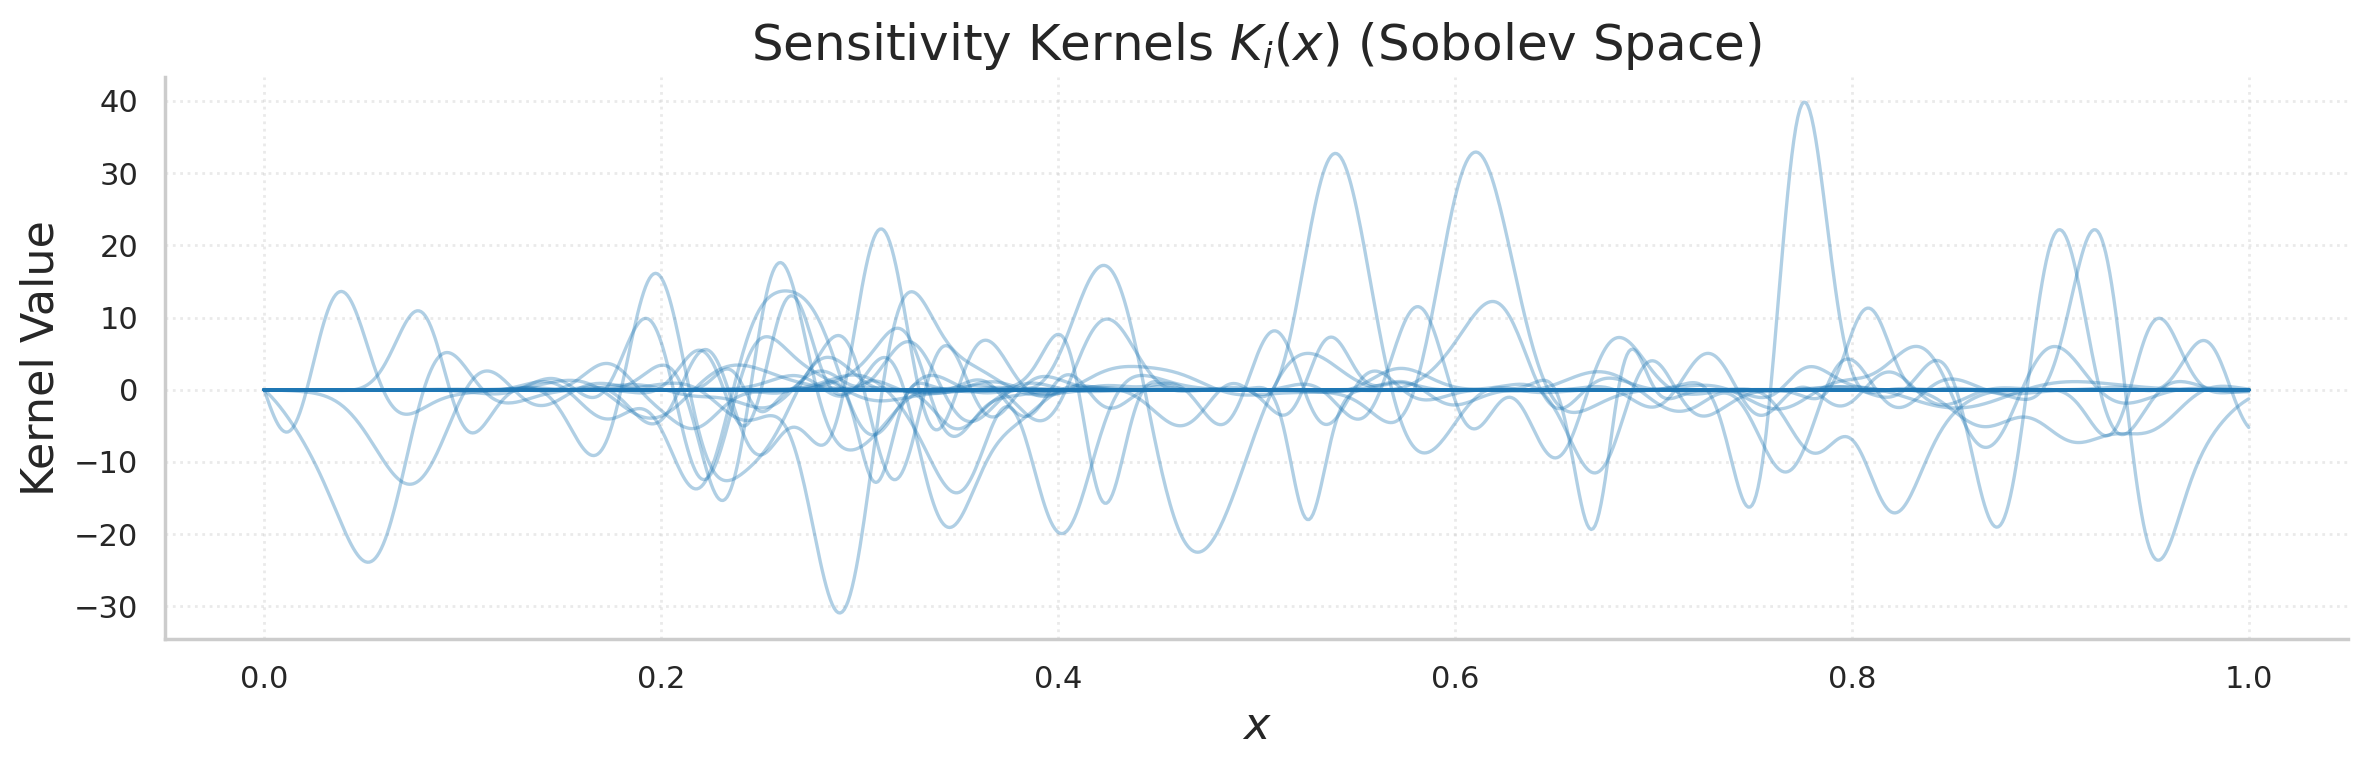

In [6]:
# Publication-quality Sensitivity Kernels figure
fig_title = "Sensitivity Kernels (Sobolev)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

x = np.linspace(function_domain.a, function_domain.b, 1000)

sns.set_theme(style="whitegrid", palette="muted", color_codes=True)
plt.figure(figsize=(12, 4), dpi=200)

# Plot all kernels in a single color - overlapping areas show regions of high sensitivity
for i in range(N_d):
    plt.plot(
        x,
        G.get_kernel(i).evaluate(x),
        color='tab:blue',
        alpha=0.35,
        linewidth=1.2
    )

plt.title(r"Sensitivity Kernels $K_i(x)$ (Sobolev Space)", fontsize=18)
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel("Kernel Value", fontsize=16)
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()

# Save as both PNG and PDF for publication
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

### Sensitivity Kernels Visualization

The sensitivity kernels $K_i(x)$ define how sensitive each data point $d_i$ is to the model $m(x)$ at different spatial locations. These kernels are crucial for understanding:

- **Coverage**: Where in the domain we have observational sensitivity
- **Resolution**: How localized our measurements are
- **Redundancy**: Overlapping kernels indicate multiple measurements of similar information

Regions where many kernels overlap (appearing darker) represent areas of high observational density, while sparse regions indicate limited sensitivity.

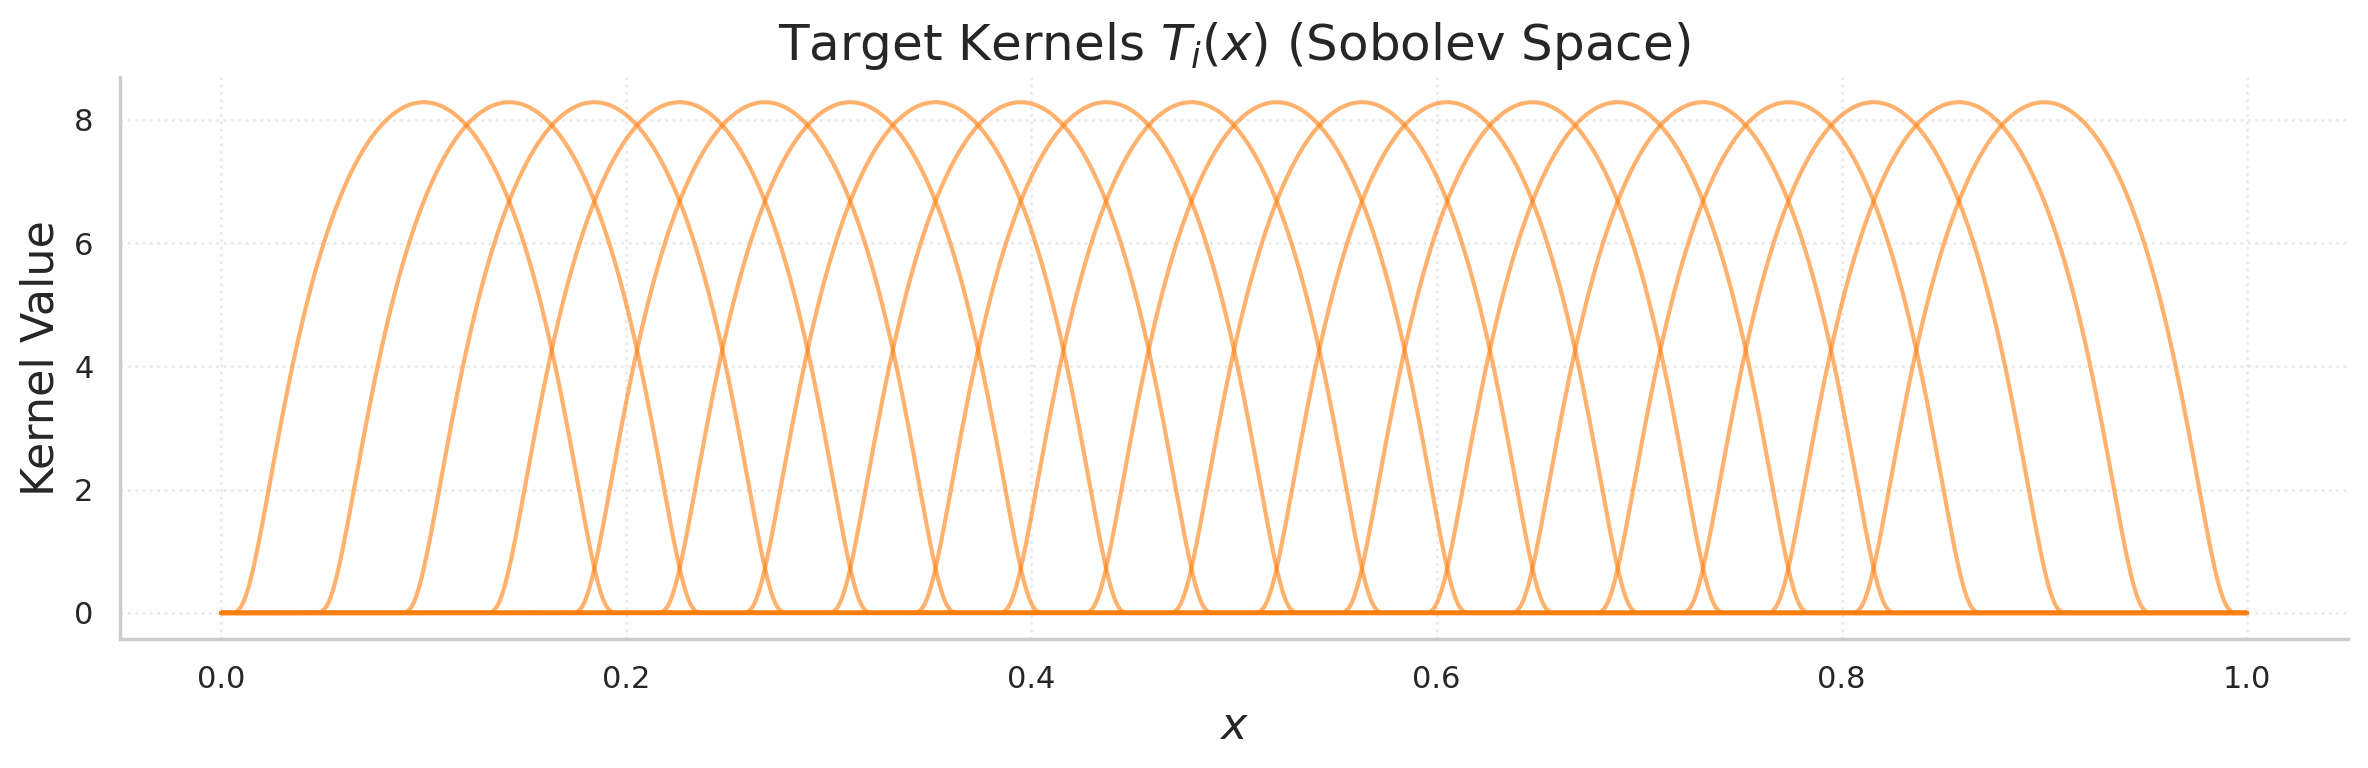

In [7]:
# Publication-quality Target Kernels figure
fig_title = "Target Kernels (Sobolev)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 4), dpi=200)
for i in range(N_p):
    plt.plot(
        x,
        T.get_kernel(i).evaluate(x),
        color='tab:orange',
        alpha=0.6,
        linewidth=1.5
    )

plt.title(r"Target Kernels $T_i(x)$ (Sobolev Space)", fontsize=18)
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel("Kernel Value", fontsize=16)
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()

# Save as both PNG and PDF
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

### Target Kernels for Property Extraction

The target kernels $T_i(x)$ define the properties we want to infer about the model. Each kernel extracts a local average of the model around its center location. These bump functions allow us to:

- **Localize**: Extract spatially localized properties
- **Regularize**: Smooth local estimates through spatial averaging  
- **Focus**: Target specific regions of interest in the domain

## Synthetic Data Generation

### True Model Construction

We create a synthetic "true" model $\bar{m}(x)$ that combines multiple scales of variation:

$$\bar{m}(x) = \exp\left(-\frac{(x - 0.5)^2}{0.5^2}\right) \sin(5\pi x) + x$$

This model includes:
- **Global trend**: Linear component $x$ 
- **Localized oscillation**: Gaussian-windowed sine wave for fine-scale structure
- **Smooth envelope**: Exponential decay for spatial localization

From this true model, we generate synthetic observations $\mathbf{\bar{d}} = G(\bar{m})$ and add noise to create realistic measurements $\mathbf{\tilde{d}}$.

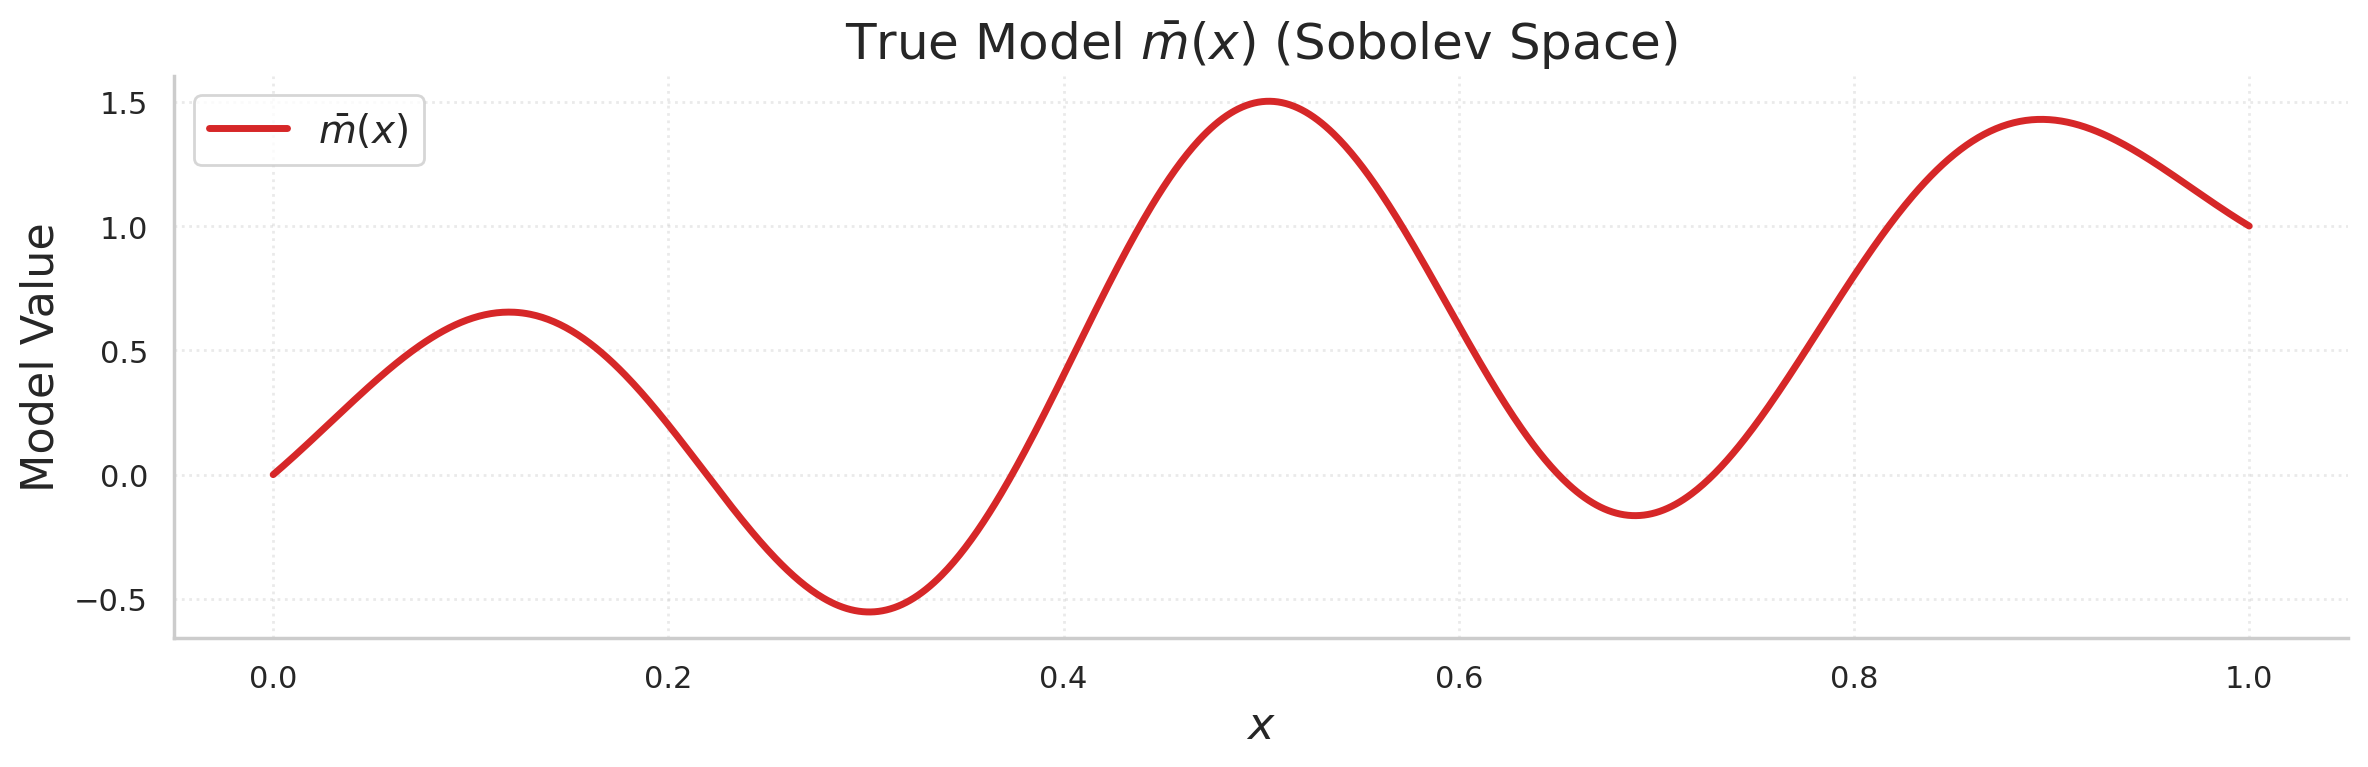

Generating synthetic data...
Signal-to-noise ratio: 10.0
Number of observations: 50


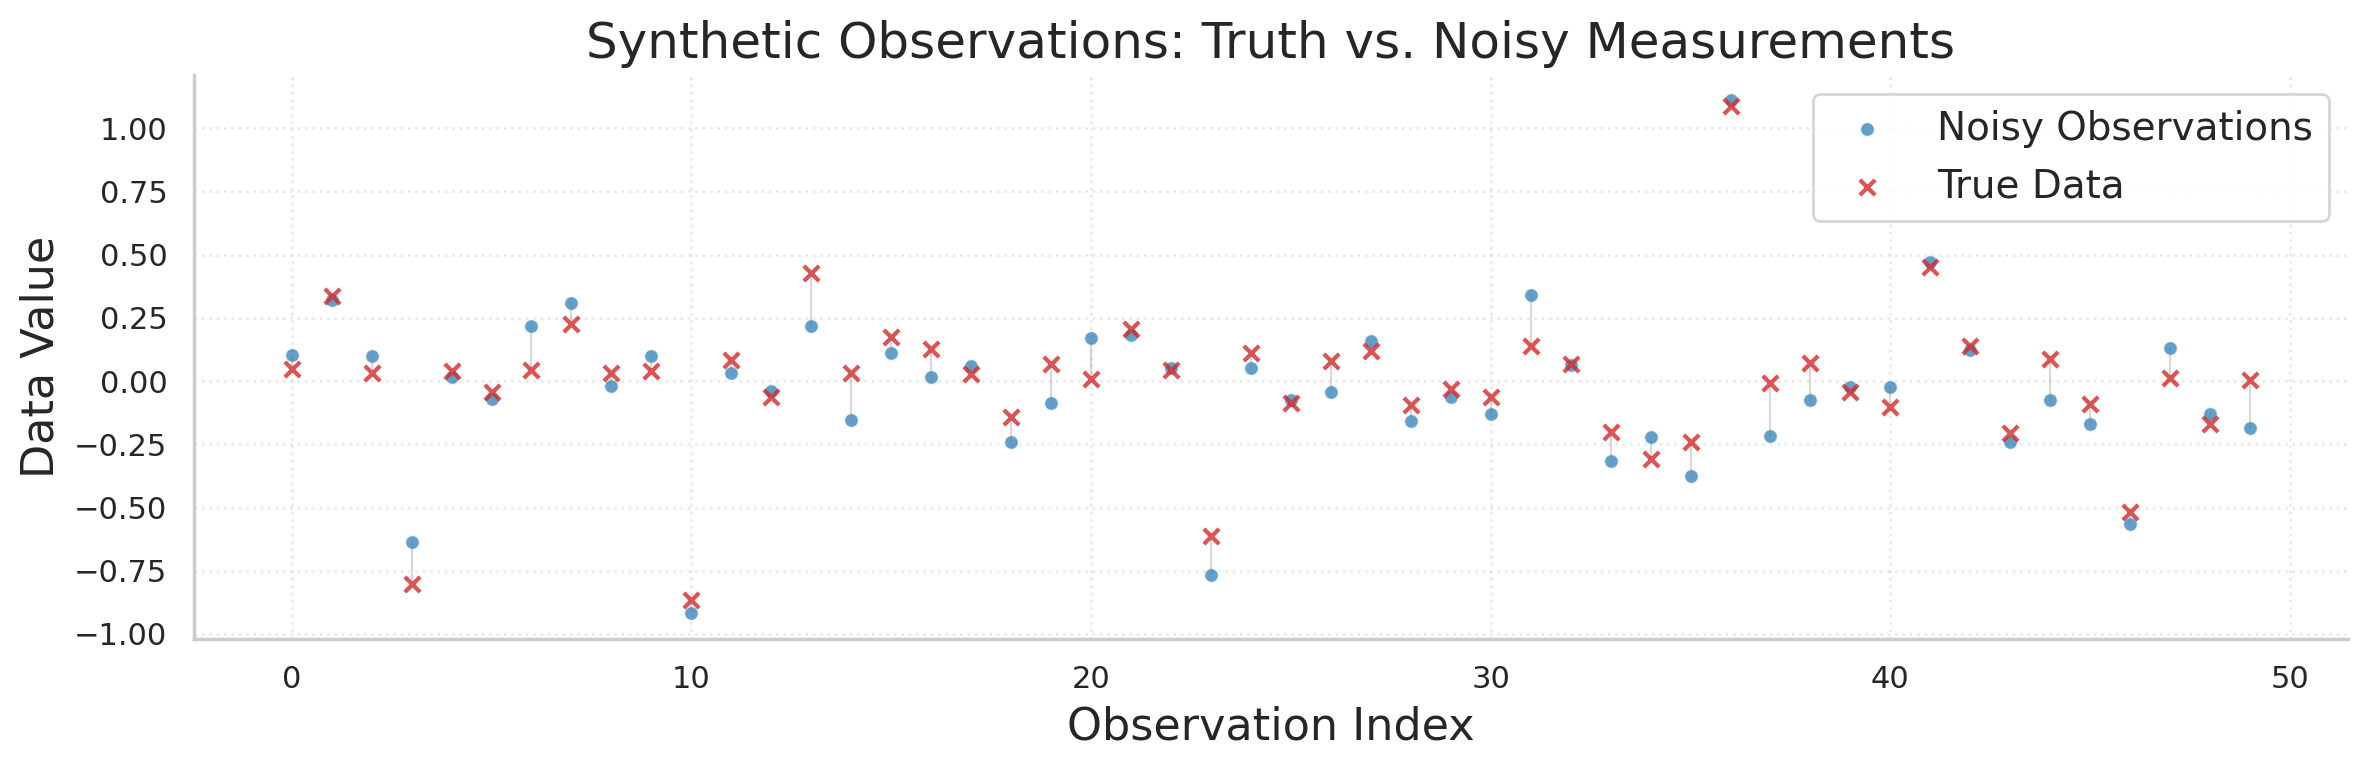

In [8]:
# Create the synthetic true model
m_bar = Function(M, evaluate_callable=lambda x: np.exp(-((x - function_domain.center)/0.5)**2) * np.sin(5 * np.pi * x) + x)

# Evaluation grid
x = np.linspace(function_domain.a, function_domain.b, 1000)

# Publication-quality true model plot
fig_title = "True Model (Sobolev)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 4), dpi=200)
plt.plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.5, label=r'$\bar{m}(x)$')
plt.title(r"True Model $\bar{m}(x)$ (Sobolev Space)", fontsize=18)
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel("Model Value", fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

# Generate synthetic observations
print("Generating synthetic data...")
d_bar = G(m_bar)  # Clean observations
noise_level = 0.1 * np.max(d_bar)
np.random.seed(42)  # For reproducibility
d_tilde = d_bar + np.random.normal(0, noise_level, d_bar.shape)  # Noisy observations

print(f"Signal-to-noise ratio: {np.max(d_bar) / noise_level:.1f}")
print(f"Number of observations: {len(d_tilde)}")

# Publication-quality data comparison plot
fig_title = "Synthetic Observations (Sobolev)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 4), dpi=200)
data_indices = np.arange(len(d_bar))

# Plot connection lines between true and noisy data
for i in range(len(d_bar)):
    plt.plot([i, i], [d_bar[i], d_tilde[i]], color='gray', alpha=0.3, linewidth=0.8)

# Plot the data points
plt.scatter(data_indices, d_tilde, label='Noisy Observations',
           color='tab:blue', alpha=0.7, marker='o', s=25, edgecolors='white', linewidths=0.5)
plt.scatter(data_indices, d_bar, label='True Data',
           color='tab:red', alpha=0.8, marker='x', s=30, linewidths=1.5)

plt.xlabel('Observation Index', fontsize=16)
plt.ylabel('Data Value', fontsize=16)
plt.title('Synthetic Observations: Truth vs. Noisy Measurements', fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## Bayesian Setup: Data and Prior Measures

### Data Noise Model

We model the measurement noise as independent Gaussian with known variance:
$$\mathbf{\eta} \sim \mathcal{N}(\mathbf{0}, \mathbf{C}_{\mathcal{D}})$$

where $\mathbf{C}_{\mathcal{D}} = \sigma^2 \mathbf{I}$ represents uncorrelated measurement errors. This gives us the data likelihood:
$$\mathbf{\tilde{d}} | m \sim \mathcal{N}(G(m), \mathbf{C}_{\mathcal{D}})$$

**Important distinction**: 
- **Data error measure**: $\mathcal{N}(\mathbf{0}, \mathbf{C}_{\mathcal{D}})$ - represents the noise model for `LinearForwardProblem`
- **Data measure**: $\mathcal{N}(\mathbf{\tilde{d}}, \mathbf{C}_{\mathcal{D}})$ - represents the observed data for visualization

In [9]:
# Define data noise covariance
noise_variance = (0.1 * np.max(d_tilde))**2  # 20% of peak signal
C_D_matrix = noise_variance * np.eye(N_d)

print(f"Data noise standard deviation: {np.sqrt(noise_variance):.4f}")
print(f"Relative noise level: {100 * np.sqrt(noise_variance) / np.max(d_tilde):.1f}%")

# Create data NOISE measure (zero mean) for LinearForwardProblem
# This represents the noise model: η ~ N(0, C_D)
gaussian_D_noise = GaussianMeasure.from_covariance_matrix(D, C_D_matrix, expectation=np.zeros(N_d))

# Create data measure (with observed data mean) for visualization
# This represents the likelihood: d̃ | m ~ N(G(m), C_D)
gaussian_D = GaussianMeasure.from_covariance_matrix(D, C_D_matrix, expectation=d_tilde)

Data noise standard deviation: 0.1111
Relative noise level: 10.0%


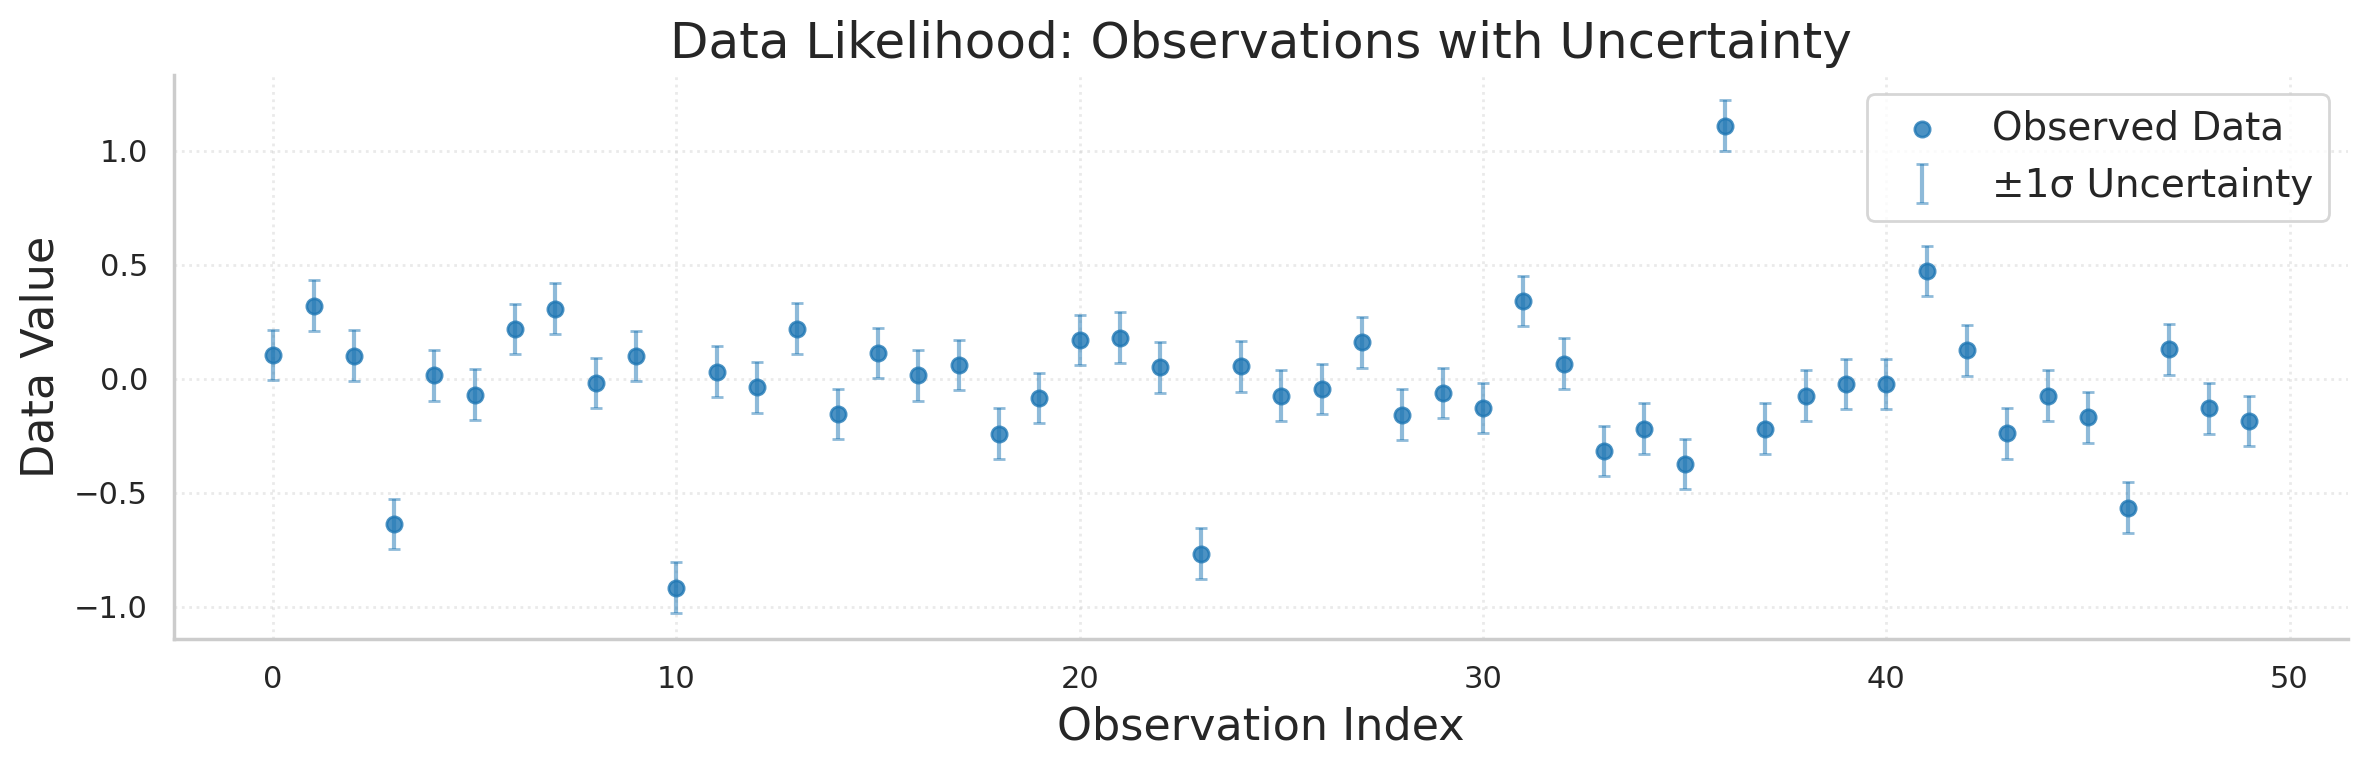

In [10]:
# Visualize the data measure (observed data with uncertainty)
mean_values = gaussian_D.expectation
std_values = np.sqrt(noise_variance)

fig_title = "Data Likelihood Distribution (Sobolev)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 4), dpi=200)
data_indices = np.arange(len(mean_values))

plt.scatter(data_indices, mean_values, label='Observed Data', color='tab:blue', alpha=0.8, s=30)
plt.errorbar(data_indices, mean_values, yerr=std_values, fmt='none',
            color='tab:blue', alpha=0.5, capsize=2, capthick=1,
            label='±1σ Uncertainty')

plt.title("Data Likelihood: Observations with Uncertainty", fontsize=18)
plt.xlabel('Observation Index', fontsize=16)
plt.ylabel('Data Value', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

### Prior Model for Sobolev Spaces

We assign a Gaussian prior measure to regularize the inverse problem:
$$m \sim \mu_{\mathcal{M}}^0 = \mathcal{N}(m_0, C_0)$$

**Prior Mean**: $m_0(x) = x$ (simple linear trend)

**Prior Covariance**: We use the inverse of the Laplacian operator:
$$C_0 = (-\alpha \Delta)^{-1}$$

where $\alpha > 0$ controls the correlation length scale. This choice:
- Enforces smooth realizations appropriate for Sobolev spaces
- Has explicit eigenfunction expansion
- Provides fast sampling via Karhunen-Loève expansion
- Respects the boundary conditions of the Sobolev space

In [11]:
# Define prior measure parameters
s_covariance = 1
length_scale_covariance = np.power(10, -0.3)
overall_variance_covariance = np.power(10, -1.0)
k_covariance = np.power(overall_variance_covariance, -0.5/s_covariance)
alpha = (length_scale_covariance**2) * k_covariance**2

L = Laplacian(M, bcs, alpha, method='spectral', dofs=100,
              n_samples=2048, integration_config=laplacian_integration_cfg)
C_0 = BesselSobolevInverse(M, M, k_covariance, s_covariance, L, dofs=100, n_samples=2048)

# Prior mean (simple linear trend)
m_0 = Function(M, evaluate_callable=lambda x: x)

print(f"Prior covariance: (-{alpha}Δ)⁻¹ with Dirichlet boundary conditions")
print(f"Prior mean: m₀(x) = x")

# Set up Karhunen-Loève expansion for efficient sampling
K = 100  # Number of KL terms (should be ≥ N for full representation)
print(f"Using {K} Karhunen-Loève terms for prior sampling")

# Create Gaussian measure on model space
sampler = KLSampler(C_0, mean=m_0, n_modes=K)
M_prior = GaussianMeasure(covariance = C_0, expectation=m_0, sample=sampler.sample)

# Display eigenvalue decay (using Laplacian eigenvalues)
laplacian_eigenvals = [L.get_eigenvalue(i) for i in range(50)]
print(f"Laplacian eigenvalue range: [{laplacian_eigenvals[-1]:.2e}, {laplacian_eigenvals[0]:.2e}]")
print(f"Spectral decay rate: {laplacian_eigenvals[0]/laplacian_eigenvals[-1]:.1e}")

Prior covariance: (-2.5118864315095792Δ)⁻¹ with Dirichlet boundary conditions
Prior mean: m₀(x) = x
Using 100 Karhunen-Loève terms for prior sampling
Laplacian eigenvalue range: [1.50e+05, 0.00e+00]
Spectral decay rate: 0.0e+00


Drawing samples from prior measure...
Computing prior uncertainty...


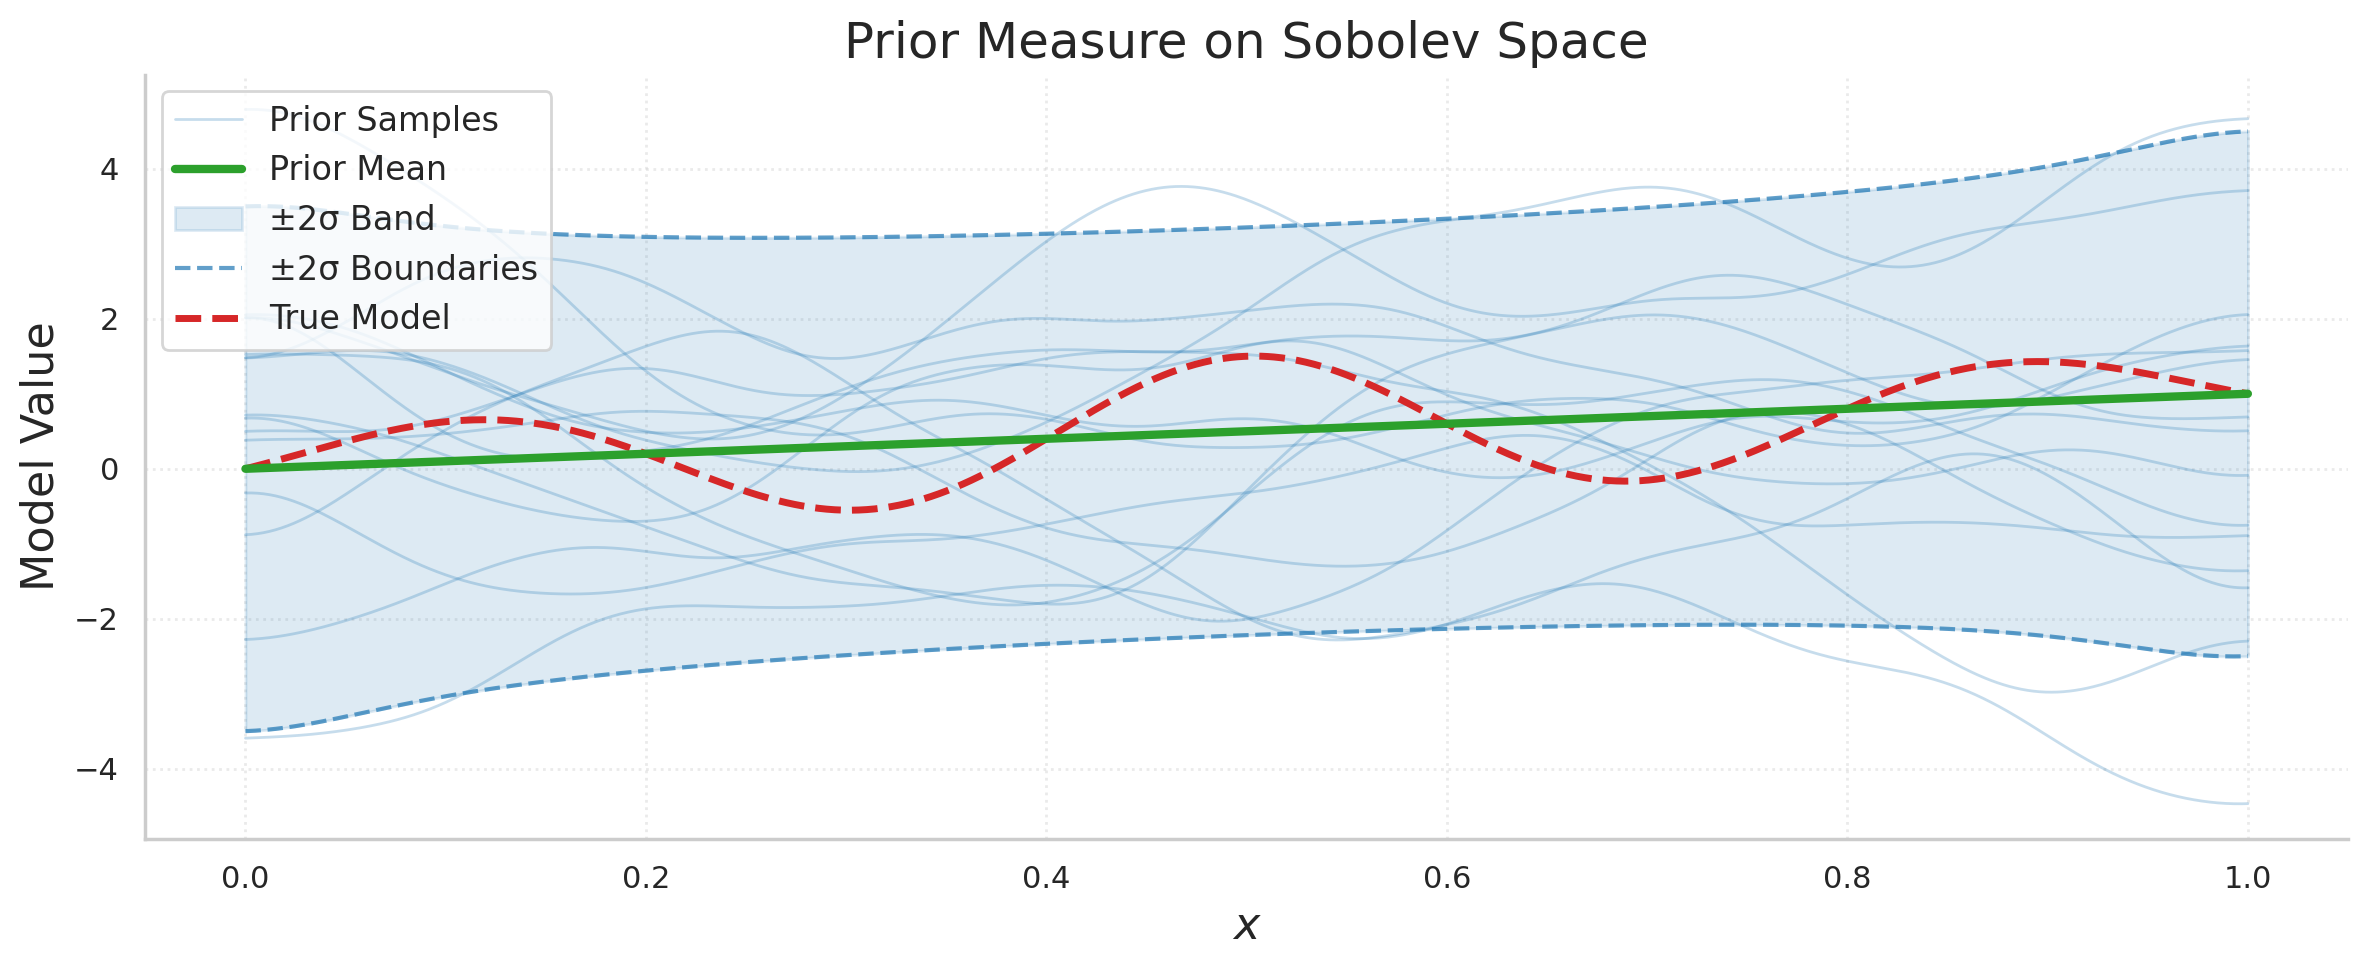

In [12]:
# Visualize the prior measure
fig_title = "Prior Measure on Model Space (Sobolev)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

# Parameters for visualization
num_samples = 15
sample_color = 'tab:blue'
mean_color = 'tab:green'
std_color = 'tab:blue'

plt.figure(figsize=(12, 5), dpi=200)

# Plot prior samples
print("Drawing samples from prior measure...")
for i in range(num_samples):
    sample = M_prior.sample()
    plt.plot(x, sample.evaluate(x), color=sample_color, alpha=0.25, linewidth=1,
            label='Prior Samples' if i == 0 else "")

# Compute and plot uncertainty bounds
print("Computing prior uncertainty...")
# Use KLSampler's variance_function for cleaner computation
variance_func = sampler.variance_function()
std_values = np.sqrt(variance_func.evaluate(x))

# Plot prior mean and uncertainty
mean_values = M_prior.expectation.evaluate(x)
plt.plot(x, mean_values, color=mean_color, linewidth=3, label='Prior Mean', zorder=10)
plt.fill_between(x, mean_values - 2*std_values, mean_values + 2*std_values,
                 color=std_color, alpha=0.15, label='±2σ Band')
plt.plot(x, mean_values + 2*std_values, color=std_color, linestyle='--',
        alpha=0.7, linewidth=1.5, label='±2σ Boundaries')
plt.plot(x, mean_values - 2*std_values, color=std_color, linestyle='--',
        alpha=0.7, linewidth=1.5)

# Plot true model
plt.plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.5,
        label='True Model', linestyle='--', zorder=9)

plt.title("Prior Measure on Sobolev Space", fontsize=18)
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel("Model Value", fontsize=16)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## Property Prior Analysis

### Push-forward of Model Prior

The property prior is obtained by pushing the model prior through the target operator:
$$\mu_{\mathcal{P}}^0 = \mathcal{T}_* \mu_{\mathcal{M}}^0 = \mathcal{N}(\mathcal{T}(m_0), \mathcal{T} C_0 \mathcal{T}^*)$$

This gives us prior beliefs about the local properties before incorporating data.

In [13]:
# Compute property prior by pushing model prior through target operator
print("Computing property prior measure...")
prior_P = M_prior.affine_mapping(operator=T)
std_P = np.sqrt(np.diag(prior_P.covariance.matrix(dense=True, galerkin=True, parallel=True, n_jobs=8)))

print(f"Property prior computed for {N_p} target locations")
print(f"Property uncertainty range: [{std_P.min():.3f}, {std_P.max():.3f}]")

Computing property prior measure...
Property prior computed for 20 target locations
Property uncertainty range: [1.134, 1.312]


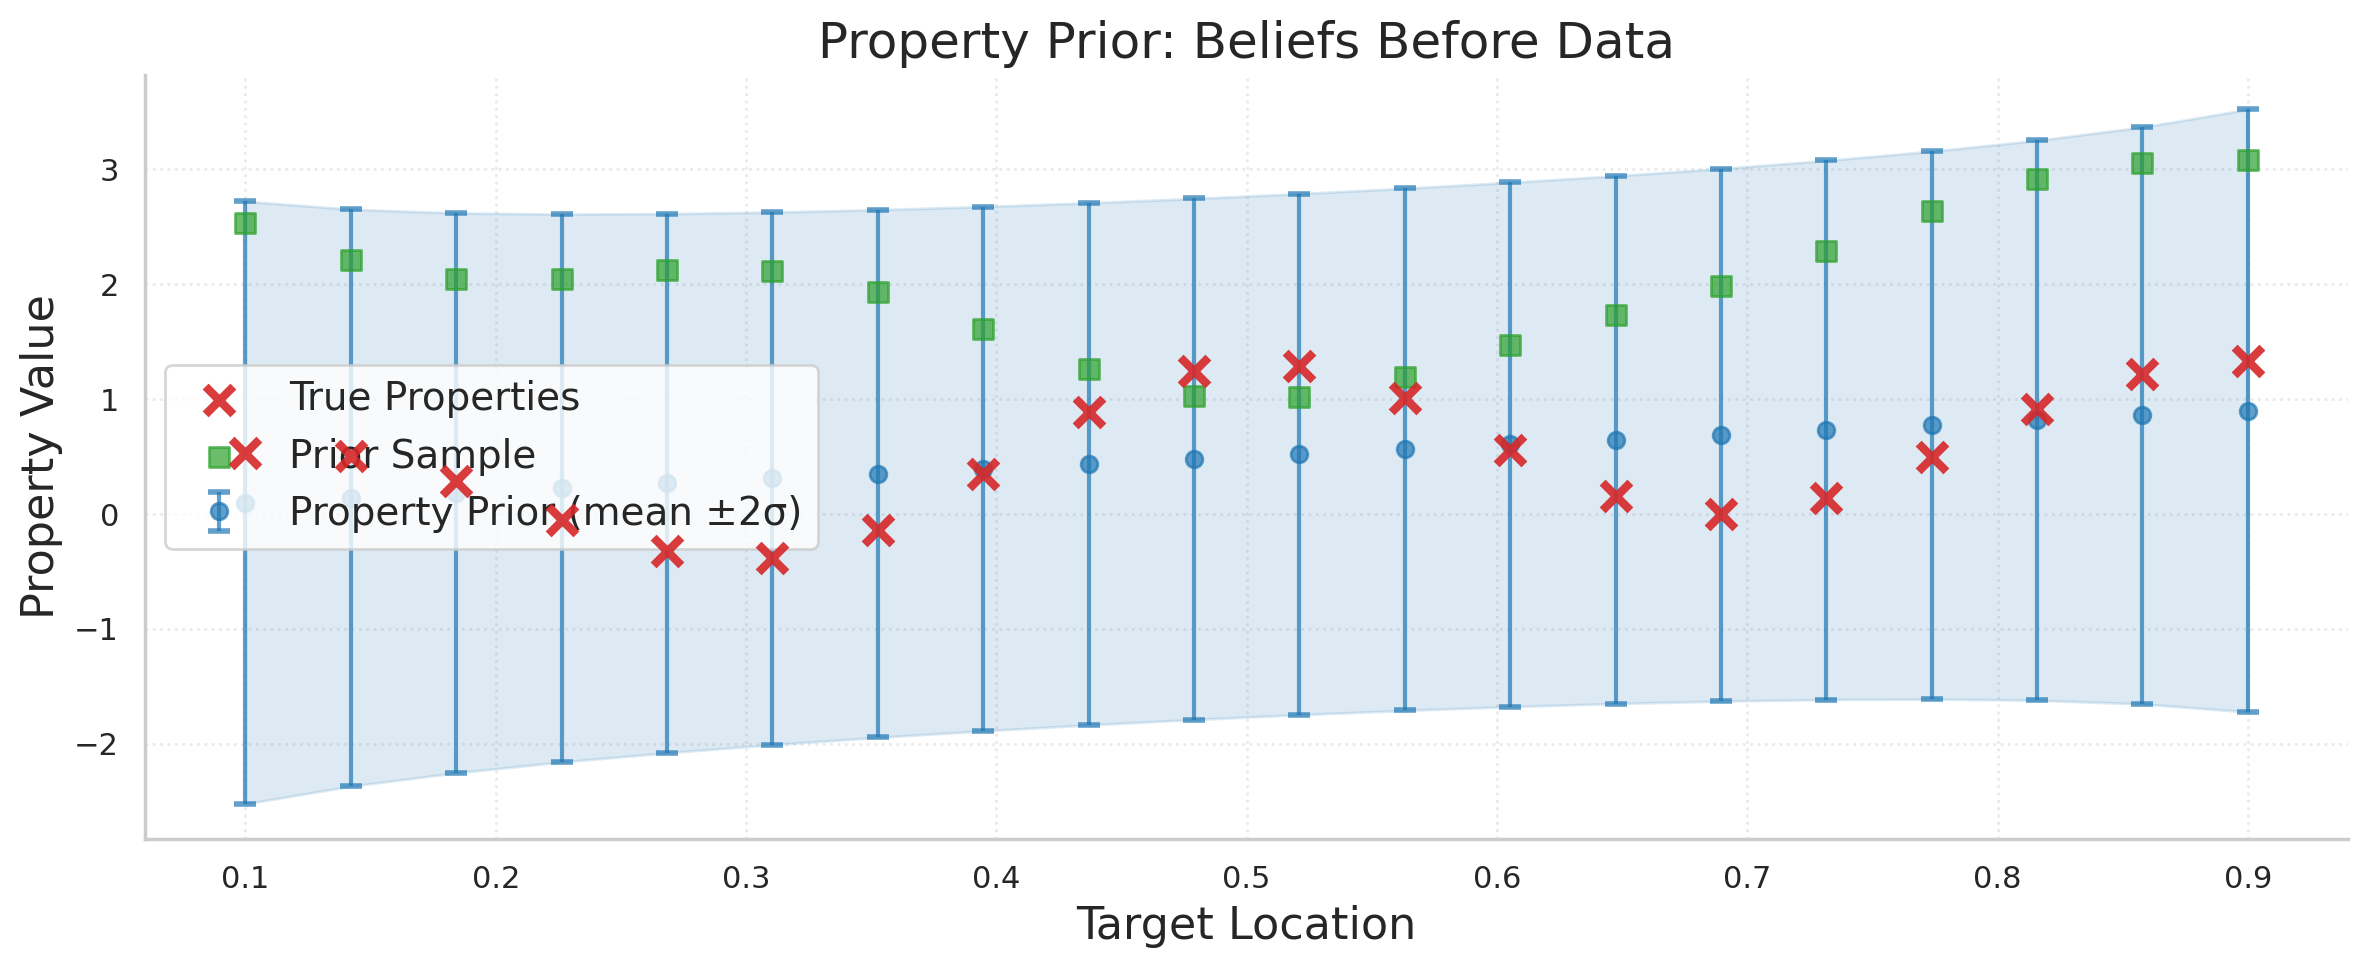

True properties range: [-0.381, 1.332]
How many true properties are within prior ±2σ: 20/20


In [14]:
# Visualize property prior
fig_title = "Property Prior Distribution (Sobolev)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 5), dpi=200)

# Property prior mean and uncertainty
mean_prop = T(M_prior.expectation)
plt.errorbar(centers, mean_prop, yerr=2*std_P, fmt='o', color='tab:blue',
            alpha=0.7, capsize=4, capthick=2, markersize=6,
            label='Property Prior (mean ±2σ)')
plt.fill_between(centers, mean_prop - 2*std_P, mean_prop + 2*std_P,
                color='tab:blue', alpha=0.15)

# True property values
true_props = T(m_bar)
plt.scatter(centers, true_props, label='True Properties',
           color='tab:red', marker='x', s=100, alpha=0.9, linewidths=3, zorder=10)

# Sample from property prior
sampled_props = prior_P.sample()
plt.scatter(centers, sampled_props, label='Prior Sample',
           color='tab:green', marker='s', s=50, alpha=0.7, zorder=5)

plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.title('Property Prior: Beliefs Before Data', fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

# Print some statistics
print(f"True properties range: [{true_props.min():.3f}, {true_props.max():.3f}]")
print(f"How many true properties are within prior ±2σ: {np.sum(np.abs(true_props - mean_prop) <= 2*std_P)}/{len(true_props)}")

## Bayesian Update: Computing the Posterior

### Model Posterior

The Bayesian update combines prior beliefs with data likelihood to give the posterior:
$$\mu_{\mathcal{M}}^{\mathbf{\tilde{d}}} = \mathcal{N}(\tilde{m}, C_{\mathcal{M}})$$

where:
- **Posterior covariance**: $C_{\mathcal{M}} = (G^* \mathbf{C}_{\mathcal{D}}^{-1} G + C_0^{-1})^{-1}$
- **Posterior mean**: $\tilde{m} = C_{\mathcal{M}}(G^* \mathbf{C}_{\mathcal{D}}^{-1} \mathbf{\tilde{d}} + C_0^{-1} m_0)$

This represents our updated beliefs about the model after incorporating the data.

In [15]:
# Bayesian inference setup and posterior computation
import time

print("="*80)
print("BAYESIAN INFERENCE")
print("="*80)

# Common setup
t0 = time.time()
print("\nSetting up Bayesian inference...")
forward_problem = LinearForwardProblem(G, data_error_measure=gaussian_D_noise)
bayesian_inference = LinearBayesianInversion(forward_problem, M_prior)
solver = CholeskySolver(parallel=True, n_jobs=8)
t1 = time.time()
print(f"   Setup time: {t1-t0:.3f}s")

if COMPUTE_MODEL_POSTERIOR:
    print("\n" + "="*80)
    print("WORKFLOW 1: Model Posterior → Property Posterior")
    print("="*80)

    # Compute model posterior measure
    print("\n1. Computing model posterior measure...")
    t2 = time.time()
    posterior_model = bayesian_inference.model_posterior_measure(d_tilde, solver)
    t3 = time.time()
    print(f"   Time: {t3-t2:.3f}s")

    # Extract dense matrix
    print("\n2. Extracting dense covariance matrix...")
    t4 = time.time()
    C_M_matrix = posterior_model.covariance.matrix(dense=True, galerkin=True, parallel=True, n_jobs=8)
    t5 = time.time()
    print(f"   Time: {t5-t4:.3f}s")

    # Create sampling-capable measure
    print("\n3. Creating sampling-capable measure...")
    t6 = time.time()
    mu_M = GaussianMeasure.from_covariance_matrix(M, C_M_matrix, expectation=posterior_model.expectation)
    m_tilde = mu_M.expectation
    t7 = time.time()
    print(f"   Time: {t7-t6:.3f}s")

    # Compute property posterior by pushing model posterior
    print("\n4. Computing property posterior (via model)...")
    t8 = time.time()
    property_posterior = mu_M.affine_mapping(operator=T)
    p_tilde = property_posterior.expectation
    cov_P_matrix = property_posterior.covariance.matrix(dense=True, galerkin=True, parallel=True, n_jobs=8)
    t9 = time.time()
    print(f"   Time: {t9-t8:.3f}s")

    total_time = t9 - t0
    print(f"\n{'='*80}")
    print(f"WORKFLOW 1 TOTAL TIME: {total_time:.3f}s")
    print(f"{'='*80}")
    print("\nBreakdown:")
    print(f"  Setup:             {(t1-t0)/total_time*100:5.1f}%  ({t1-t0:.3f}s)")
    print(f"  Model posterior:   {(t3-t2)/total_time*100:5.1f}%  ({t3-t2:.3f}s)")
    print(f"  Dense matrix:      {(t5-t4)/total_time*100:5.1f}%  ({t5-t4:.3f}s)")
    print(f"  Measure creation:  {(t7-t6)/total_time*100:5.1f}%  ({t7-t6:.3f}s)")
    print(f"  Property posterior:{(t9-t8)/total_time*100:5.1f}%  ({t9-t8:.3f}s)")

else:
    print("\n" + "="*80)
    print("WORKFLOW 2: Property Posterior Directly (Skip Model)")
    print("="*80)

    # Compute model posterior mean only (no dense covariance)
    print("\n1. Computing model posterior (mean only)...")
    t2 = time.time()
    posterior_model = bayesian_inference.model_posterior_measure(d_tilde, solver)
    m_tilde = posterior_model.expectation
    t3 = time.time()
    print(f"   Time: {t3-t2:.3f}s")

    # Push to property space (fast - no dense matrices involved)
    print("\n2. Computing property posterior...")
    t4 = time.time()
    property_posterior = posterior_model.affine_mapping(operator=T)
    p_tilde = property_posterior.expectation
    t5 = time.time()
    print(f"   Time: {t5-t4:.3f}s")

    # Extract only the small property covariance matrix
    print("\n3. Extracting property covariance...")
    t6 = time.time()
    cov_P_matrix = property_posterior.covariance.matrix(dense=True, galerkin=True, parallel=True, n_jobs=8)
    t7 = time.time()
    print(f"   Time: {t7-t6:.3f}s")

    total_time = t7 - t0
    print(f"\n{'='*80}")
    print(f"WORKFLOW 2 TOTAL TIME: {total_time:.3f}s")
    print(f"{'='*80}")
    print("\nBreakdown:")
    print(f"  Setup:             {(t1-t0)/total_time*100:5.1f}%  ({t1-t0:.3f}s)")
    print(f"  Model posterior:   {(t3-t2)/total_time*100:5.1f}%  ({t3-t2:.3f}s)")
    print(f"  Push to property:  {(t5-t4)/total_time*100:5.1f}%  ({t5-t4:.3f}s)")
    print(f"  Property cov:      {(t7-t6)/total_time*100:5.1f}%  ({t7-t6:.3f}s)")
    print("\n💡 Skipped expensive dense model covariance extraction!")

print(f"{'='*80}")

# Data fit (works for both workflows)
data_misfit = np.linalg.norm(G(m_tilde) - d_tilde)
print(f"\nData misfit (posterior): {data_misfit:.4f}")
print(f"Data misfit (prior):     {np.linalg.norm(G(m_0) - d_tilde):.4f}")

# Show improvement
relative_improvement = 1 - data_misfit / np.linalg.norm(G(m_0) - d_tilde)
print(f"Data fit improvement: {100 * relative_improvement:.1f}%")

BAYESIAN INFERENCE

Setting up Bayesian inference...
   Setup time: 0.000s

WORKFLOW 1: Model Posterior → Property Posterior

1. Computing model posterior measure...
   Time: 3.784s

2. Extracting dense covariance matrix...
   Time: 22.640s

3. Creating sampling-capable measure...
   Time: 0.256s

4. Computing property posterior (via model)...
   Time: 2.948s

WORKFLOW 1 TOTAL TIME: 29.629s

Breakdown:
  Setup:               0.0%  (0.000s)
  Model posterior:    12.8%  (3.784s)
  Dense matrix:       76.4%  (22.640s)
  Measure creation:    0.9%  (0.256s)
  Property posterior:  9.9%  (2.948s)

Data misfit (posterior): 0.6582
Data misfit (prior):     1.6428
Data fit improvement: 59.9%


Sampling from model posterior...


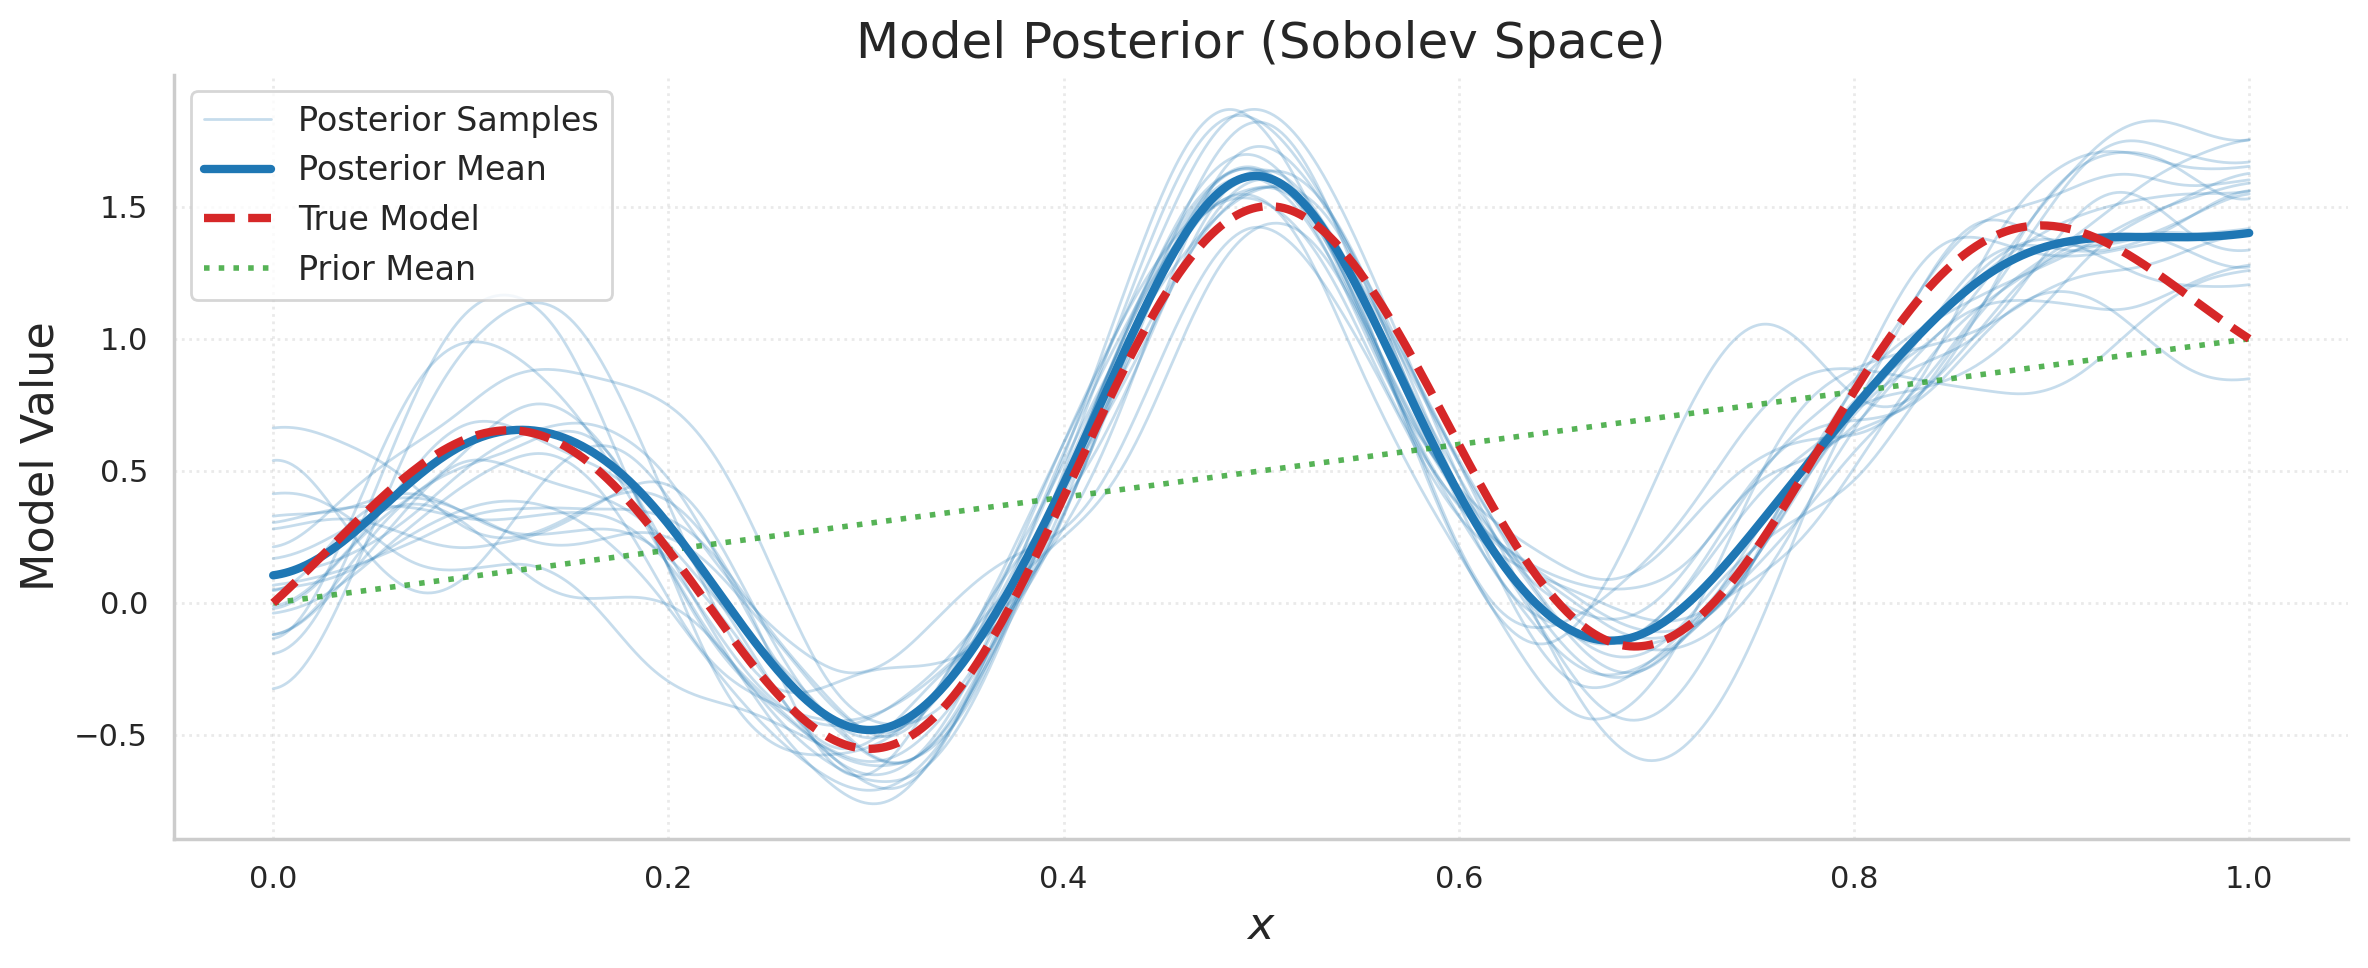

RMS reconstruction error: 0.1053
Relative error: 17.0%


In [16]:
if COMPUTE_MODEL_POSTERIOR:
    # Visualize posterior measure on model space with samples
    fig_title = "Model Posterior Distribution (Sobolev)"
    filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

    # Plot posterior samples
    num_samples = 20
    sample_color = 'tab:blue'

    plt.figure(figsize=(12, 5), dpi=200)

    print("Sampling from model posterior...")
    for i in range(num_samples):
        sample = mu_M.sample()
        plt.plot(x, sample.evaluate(x), color=sample_color, alpha=0.25, linewidth=1,
                label='Posterior Samples' if i == 0 else "")

    # Plot posterior mean, true model, and prior mean
    plt.plot(x, m_tilde.evaluate(x), color='tab:blue', linewidth=3,
            label='Posterior Mean', zorder=10)
    plt.plot(x, m_bar.evaluate(x), color='tab:red', linestyle='--', linewidth=3,
            label='True Model', zorder=10)
    plt.plot(x, M_prior.expectation.evaluate(x), color='tab:green',
            linestyle=':', linewidth=2, alpha=0.8, label='Prior Mean', zorder=5)

    plt.title("Model Posterior (Sobolev Space)", fontsize=18)
    plt.xlabel(r"$x$", fontsize=16)
    plt.ylabel("Model Value", fontsize=16)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
    plt.show()

    # Compute reconstruction error
    reconstruction_error = np.sqrt(np.mean((m_tilde.evaluate(x) - m_bar.evaluate(x))**2))
    print(f"RMS reconstruction error: {reconstruction_error:.4f}")
    print(f"Relative error: {100 * reconstruction_error / np.std(m_bar.evaluate(x)):.1f}%")

else:
    # Visualize posterior mean only (no samples, no dense covariance)
    fig_title = "Model Posterior Mean (Sobolev)"
    filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

    plt.figure(figsize=(12, 5), dpi=200)

    # Plot posterior mean, true model, and prior mean
    plt.plot(x, m_tilde.evaluate(x), color='tab:blue', linewidth=3,
            label='Posterior Mean', zorder=10)
    plt.plot(x, m_bar.evaluate(x), color='tab:red', linestyle='--', linewidth=3,
            label='True Model', zorder=10)
    plt.plot(x, M_prior.expectation.evaluate(x), color='tab:green',
            linestyle=':', linewidth=2, alpha=0.8, label='Prior Mean', zorder=5)

    plt.title("Model Posterior Mean (Sobolev Space, Fast Workflow)", fontsize=18)
    plt.xlabel(r"$x$", fontsize=16)
    plt.ylabel("Model Value", fontsize=16)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
    plt.show()

    # Compute reconstruction error
    reconstruction_error = np.sqrt(np.mean((m_tilde.evaluate(x) - m_bar.evaluate(x))**2))
    print(f"RMS reconstruction error: {reconstruction_error:.4f}")
    print(f"Relative error: {100 * reconstruction_error / np.std(m_bar.evaluate(x)):.1f}%")
    print("\n💡 Note: Skipped sampling (no dense model covariance computed)")

### Property Posterior 

We can directly compute the property posterior without explicitly constructing the full model posterior:
$$\mu_{\mathcal{P}}^{\mathbf{\tilde{d}}} = \mathcal{N}(\mathbf{\tilde{p}}, \mathbf{C}_{\mathcal{P}})$$

where:
- **Property mean**: $\mathbf{\tilde{p}} = \mathcal{T}(\tilde{m})$ 
- **Property covariance**: $\mathbf{C}_{\mathcal{P}} = \mathcal{T} C_{\mathcal{M}} \mathcal{T}^*$

This represents our final inferences about the local properties of interest.

In [17]:
# Property posterior already computed in main inference cell
# Just verify variables exist

if 'p_tilde' not in locals() or 'cov_P_matrix' not in locals():
    raise RuntimeError("Property posterior not computed - run inference cell above first")

print(f"✓ Property posterior available")
print(f"  Property mean computed for {len(p_tilde)} locations")
print(f"  Property covariance matrix size: {cov_P_matrix.shape}")

✓ Property posterior available
  Property mean computed for 20 locations
  Property covariance matrix size: (20, 20)


In [18]:
# Create sampling-capable property posterior measure
gaussian_P = GaussianMeasure.from_covariance_matrix(P, cov_P_matrix, expectation=p_tilde)
print("Property posterior Gaussian measure created successfully")

Property posterior Gaussian measure created successfully


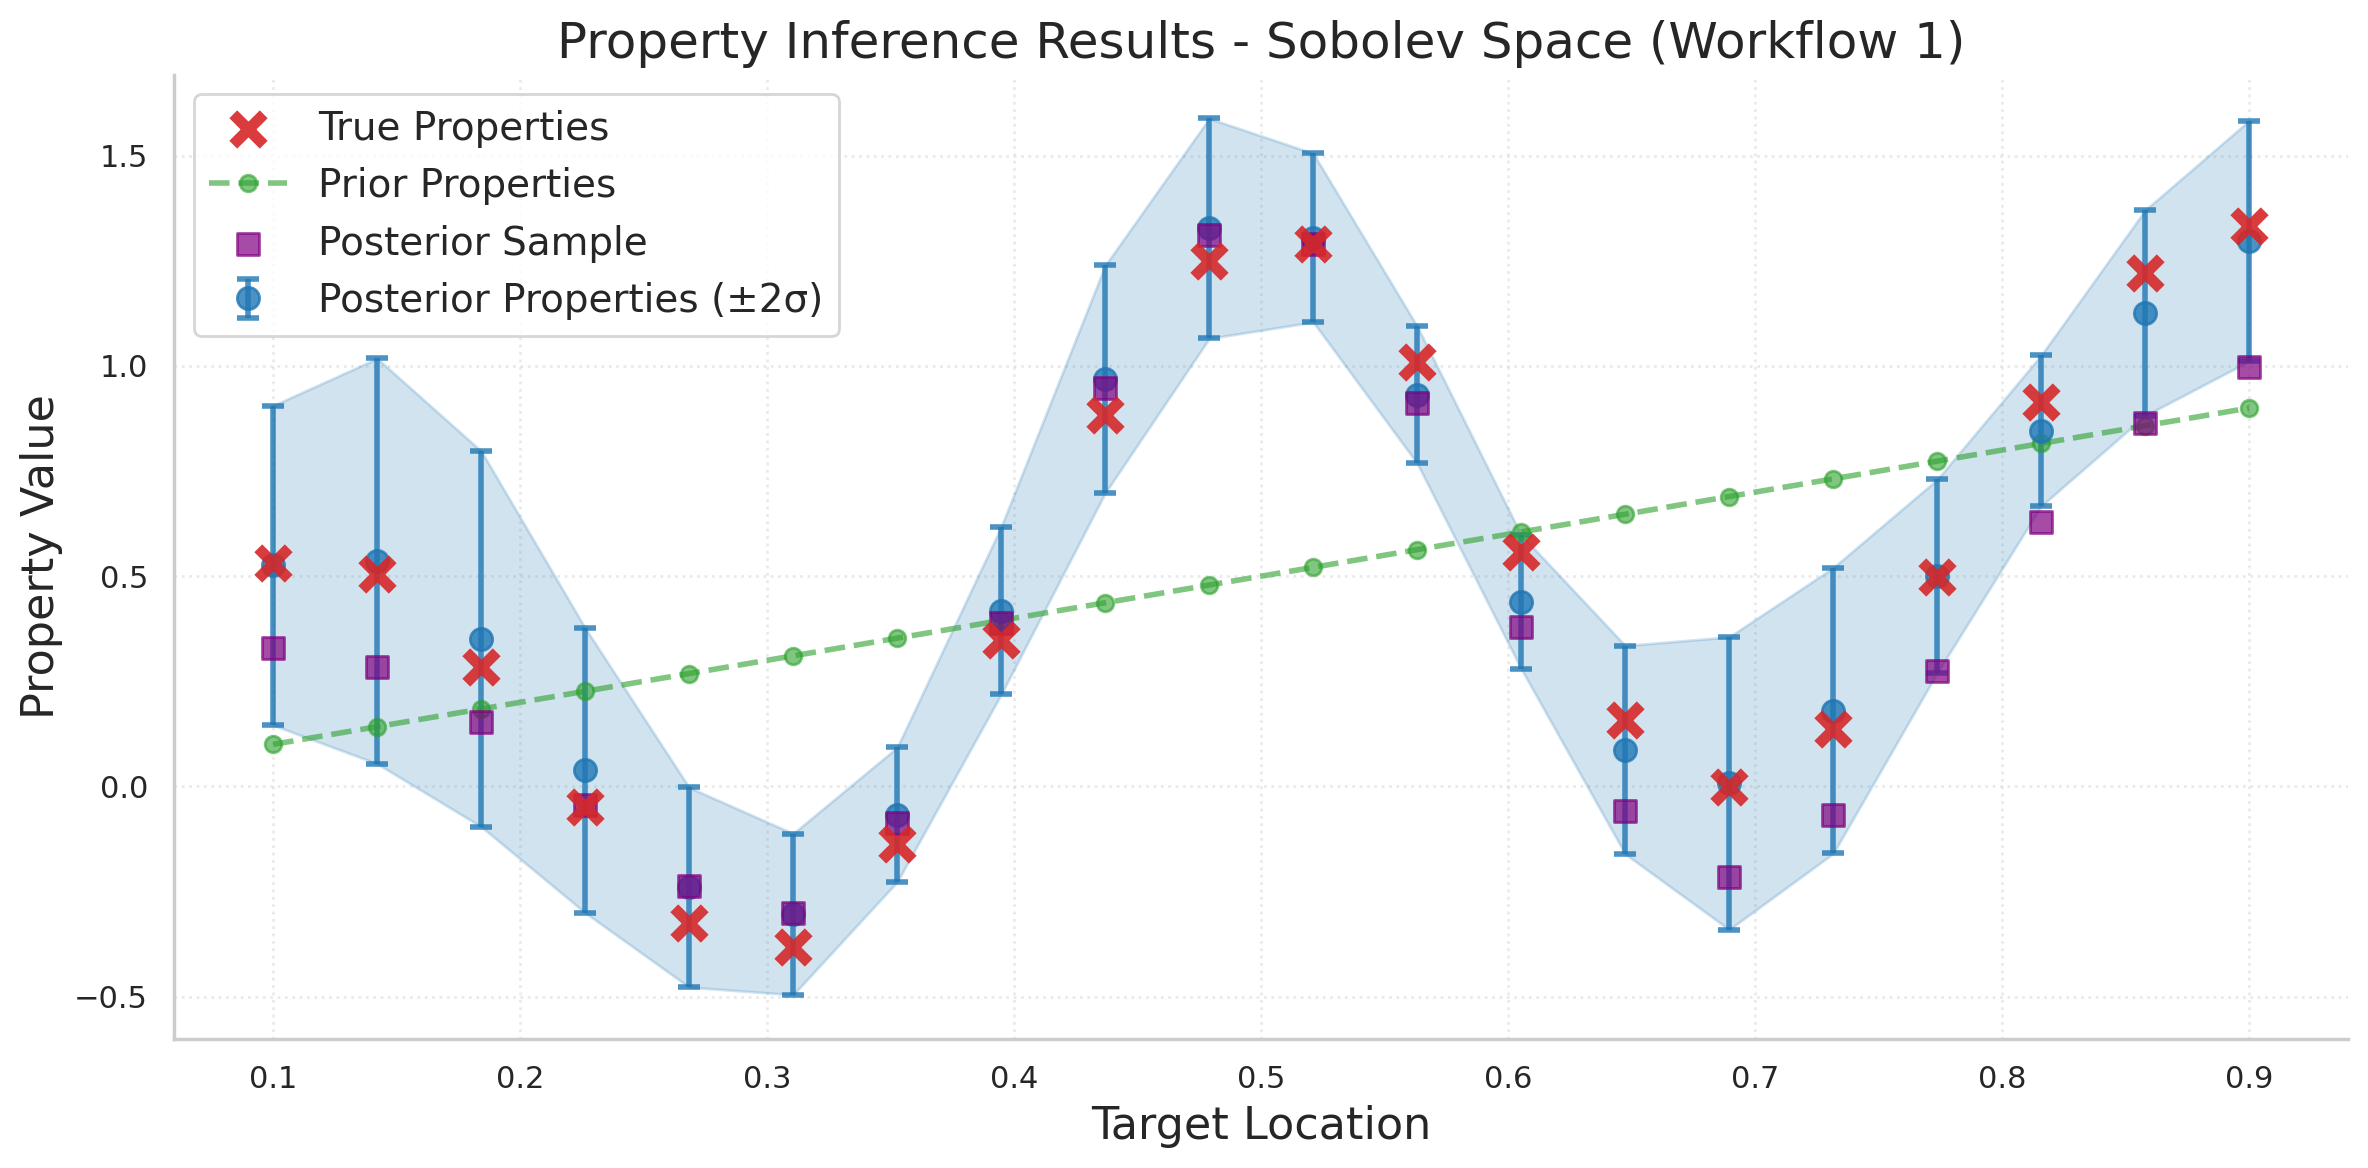


FINAL RESULTS SUMMARY
Workflow: 1 (via model posterior)
Properties successfully inferred: 20/20 (100.0%)
Mean absolute error: 0.0596
RMS error: 0.0679
Max error: 0.1191
Average uncertainty reduction: 88.7%


In [19]:
# Final property inference results
std_P_post = np.sqrt(np.diag(cov_P_matrix))

fig_title = "Property Inference Results (Sobolev)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 6), dpi=200)

# Property posterior with uncertainty
plt.errorbar(centers, p_tilde, yerr=2*std_P_post, fmt='o', color='tab:blue',
            alpha=0.8, capsize=4, capthick=2, markersize=8, linewidth=2,
            label='Posterior Properties (±2σ)')
plt.fill_between(centers, p_tilde - 2*std_P_post, p_tilde + 2*std_P_post,
                color='tab:blue', alpha=0.2)

# True properties
true_props = T(m_bar)
plt.scatter(centers, true_props, label='True Properties',
           color='tab:red', marker='x', s=120, alpha=0.9, linewidths=4, zorder=10)

# Prior for comparison
mean_prop_prior = T(M_prior.expectation)
plt.plot(centers, mean_prop_prior, 'o--', color='tab:green', alpha=0.6,
        markersize=6, linewidth=2, label='Prior Properties')

# Sample from posterior (only if we have full covariance)
if COMPUTE_MODEL_POSTERIOR:
    sampled_props_post = gaussian_P.sample()
    plt.scatter(centers, sampled_props_post, label='Posterior Sample',
               color='purple', marker='s', s=60, alpha=0.7, zorder=5)

workflow_label = "Workflow 1" if COMPUTE_MODEL_POSTERIOR else "Workflow 2 (Fast)"
plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.title(f'Property Inference Results - Sobolev Space ({workflow_label})', fontsize=18)
plt.legend(fontsize=14, loc='best')
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

# Quantitative assessment
property_errors = np.abs(p_tilde - true_props)
within_2sigma = np.sum(property_errors <= 2*std_P_post)

print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"Workflow: {'1 (via model posterior)' if COMPUTE_MODEL_POSTERIOR else '2 (direct - fast)'}")
print(f"Properties successfully inferred: {within_2sigma}/{len(true_props)} ({100*within_2sigma/len(true_props):.1f}%)")
print(f"Mean absolute error: {np.mean(property_errors):.4f}")
print(f"RMS error: {np.sqrt(np.mean(property_errors**2)):.4f}")
print(f"Max error: {np.max(property_errors):.4f}")
print(f"Average uncertainty reduction: {100*(1 - np.mean(std_P_post)/np.mean(std_P)):.1f}%")
print("="*50)

## Performance Notes

### Two Workflows Compared

This notebook supports two computational workflows controlled by `COMPUTE_MODEL_POSTERIOR`:

#### Workflow 1: Model Posterior → Property Posterior (Slower but Complete)
Set `COMPUTE_MODEL_POSTERIOR = True`

**Steps:**
1. Compute model posterior measure
2. Extract dense N×N model covariance matrix (⚠️ expensive!)
3. Create sampling-capable model measure
4. Push to property space via $\mathcal{T}$
5. Extract property covariance

**Advantages:**
- Can sample from model posterior
- Full model posterior visualization with uncertainty bands

**Disadvantages:**
- Slow: ~60-90 seconds for typical parameters
- Memory intensive: O(N²) dense matrix

#### Workflow 2: Property Posterior Directly (Faster, Properties Only)
Set `COMPUTE_MODEL_POSTERIOR = False`

**Steps:**
1. Compute property posterior measure directly
2. Extract small N_p×N_p property covariance (fast!)
3. Compute model posterior mean only (no covariance)

**Advantages:**
- Fast: ~15-20 seconds for typical parameters
- Memory efficient: only O(N_p²) where N_p << N
- Identical property posterior results

**Disadvantages:**
- Cannot sample from model posterior
- Model space visualization shows mean only

### Speedup Analysis

For typical parameters (N~100 DOFs, N_p=20):
- **Workflow 1**: ~60-90 seconds
- **Workflow 2**: ~15-20 seconds  
- **Speedup**: ~4x

The bottleneck in Workflow 1 is extracting the dense model covariance matrix, which requires O(N²) operator applications.

### Recommendation

**Use Workflow 2** (`COMPUTE_MODEL_POSTERIOR = False`) when:
- You only care about property inference (most applications!)
- Speed matters
- Memory is limited

**Use Workflow 1** (`COMPUTE_MODEL_POSTERIOR = True`) when:
- You need samples from the model posterior
- You want full model space uncertainty visualization
- You're computing multiple different property posteriors from the same model posterior